In [1]:
!pip install sqlalchemy pymysql pandas;

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 687.5 kB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine

In [3]:
df = pd.read_csv('/content/customer_shopping_behavior.csv')

In [4]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [5]:
df.tail(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
5040,926,22,Male,Jeans,Clothing,88.0,Arizona,L,Teal,Winter,4.9,Yes,Express,Yes,8.0,Cash,Monthly
5041,826,27,Male,Belt,Accessories,94.0,Nebraska,XL,Brown,Fall,3.6,Yes,Next Day Air,Yes,17.0,Cash,Monthly
5042,1721,25,Male,Shorts,Clothing,84.0,Massachusetts,S,Beige,Winter,2.8,No,Express,No,40.0,Debit Card,Bi-Weekly
5043,2398,37,Male,Sunglasses,Accessories,26.0,West Virginia,L,Black,Fall,2.9,No,Store Pickup,No,41.0,Venmo,Monthly
5044,2229,54,Male,Gloves,Accessories,50.0,Kansas,M,Green,Fall,3.7,No,Free Shipping,No,5.0,Credit Card,Weekly
5045,913,24,Male,Hoodie,Clothing,56.0,Arkansas,M,Green,Winter,3.4,Yes,Next Day Air,Yes,32.0,Bank Transfer,Monthly
5046,3466,19,Female,Backpack,Accessories,53.0,Iowa,M,Gold,Spring,3.4,No,Standard,No,31.0,Debit Card,Weekly
5047,3572,70,Female,Skirt,Clothing,27.0,North Dakota,M,White,Summer,3.2,No,Standard,No,15.0,Bank Transfer,Every 3 Months
5048,3195,43,Female,Sneakers,Footwear,52.0,Maryland,L,Gold,Summer,4.6,No,Standard,No,10.0,Credit Card,Bi-Weekly
5049,1832,62,Male,Blouse,Clothing,71.0,Maine,M,Cyan,Summer,3.3,No,Free Shipping,No,5.0,Bank Transfer,Every 3 Months


In [6]:
df.sample(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
1000,4589,33,Female,Headphones,Accessories,NaN,New York,L,Red,Summer,2.0,No,Express,No,NaN,Debit Card,Weekly
4019,2049,45,Male,Sneakers,Footwear,64.00,Michigan,XL,Pink,Winter,3.9,No,Express,No,35.0,Bank Transfer,Quarterly
2536,1467,58,Male,Shorts,Clothing,71.00,Alabama,M,Green,Summer,4.5,No,Store Pickup,Yes,3.0,PayPal,Annually
1349,4641,30,Female,Laptop,Electronics,822.03,Los Angeles,NaN,Red,Summer,NaN,No,Express,Yes,NaN,Debit Card,Weekly
2941,276,48,Male,Backpack,Accessories,85.00,Virginia,XL,Lavender,Winter,4.0,Yes,Express,Yes,13.0,Credit Card,Weekly
4930,4100,52,Other,Shoes,Electronics,1095.73,New York,NaN,Green,Autumn,5.0,No,Express,Yes,16.0,Cash,Quarterly
284,922,70,Male,Coat,Outerwear,24.00,South Dakota,L,Silver,Summer,4.1,Yes,Express,Yes,18.0,PayPal,Weekly
3260,1962,47,Male,Boots,Footwear,59.00,Nevada,L,Black,Summer,2.6,No,Free Shipping,No,45.0,Debit Card,Quarterly
1109,3442,64,Female,Sweater,Clothing,96.00,Tennessee,XL,Charcoal,Fall,4.1,No,Standard,No,15.0,Credit Card,Annually
2254,4068,42,Male,Shirt,Electronics,357.92,Phoenix,NaN,Green,Winter,NaN,No,Standard,Yes,0.0,Cash,Monthly


In [7]:
df.shape

(5050, 17)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   object 
 7   Size                    4680 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Previous Purchases      4502 non-null   

In [9]:
df.isnull().sum().sort_values(ascending=False)

,0
Review Rating,601
Purchase Amount (USD),556
Previous Purchases,548
Size,370
Customer ID,0
Category,0
Item Purchased,0
Age,0
Gender,0
Color,0


In [10]:
df.isnull().sum().sort_values(ascending=False)/len(df)*100

,0
Review Rating,11.900990
Purchase Amount (USD),11.009901
Previous Purchases,10.851485
Size,7.326733
Customer ID,0.000000
Category,0.000000
Item Purchased,0.000000
Age,0.000000
Gender,0.000000
Color,0.000000


In [11]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,5050.000000,5050.000000,4494.000000,4449.000000,4502.000000
mean,2519.570891,44.150495,144.765236,3.668195,25.221901
std,1470.402964,15.282328,275.590101,0.865357,14.521635
min,1.000000,18.000000,10.120000,1.000000,0.000000
25%,1252.250000,31.000000,41.000000,3.000000,13.000000
50%,2499.500000,44.000000,65.000000,3.700000,25.000000
75%,3740.750000,57.000000,89.000000,4.400000,38.000000
max,5099.000000,70.000000,1499.760000,5.000000,50.000000


In [12]:
df.describe(include='O')

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Payment Method,Frequency of Purchases
count,5050,5050,5050,5050,4680,5050,5050,5050,5050,5050,5050,5050
unique,3,30,5,54,4,25,5,2,6,2,6,7
top,Male,Shirt,Clothing,New York,M,Black,Spring,No,Standard,No,Credit Card,Monthly
freq,3018,320,2130,337,1981,404,1280,3462,1213,2789,954,946


# **DATA CLEANING**
First would check data manually in excel and then programmatically.



> First covert data in excel into table, then look for blanks in each column.

> If blanks are found in excel columns that are not in python, it means those blanks could have been converted into a blank string while inserting the data into Python.

> Look for those blanks in Python using REGEX. This method works highly efficiently.









In [13]:
pd.set_option('display.max_colwidth',None)

In [14]:
df.groupby('Category')['Item Purchased'].unique()

,Item Purchased
Category,
Accessories,"[Sunglasses, Gloves, Jewelry, Hat, Handbag, Phone, Backpack, Belt, Bag, Headphones, Scarf, Watch, Shirt, Shoes, Laptop]"
Clothing,"[T-shirt, Shirt, Shorts, Shoes, Hoodie, Phone, Pants, Socks, Jeans, Bag, Blouse, Skirt, Sweater, Watch, Laptop, Dress, Headphones]"
Electronics,"[Laptop, Phone, Watch, Bag, Shoes, Shirt, Headphones]"
Footwear,"[Shoes, Sandals, Sneakers, Boots]"
Outerwear,"[Coat, Jacket]"


In [15]:
#correctly mapped the categories with the items that belonged there.
new_mapping = {
    # Clothing
    "T-shirt": "Clothing", "Shirt": "Clothing", "Shorts": "Clothing",
    "Hoodie": "Clothing", "Pants": "Clothing", "Socks": "Clothing",
    "Jeans": "Clothing", "Blouse": "Clothing", "Skirt": "Clothing",
    "Sweater": "Clothing", "Dress": "Clothing",

    # Accessories
    "Sunglasses": "Accessories", "Gloves": "Accessories",
    "Jewelry": "Accessories", "Hat": "Accessories",
    "Handbag": "Accessories", "Backpack": "Accessories",
    "Belt": "Accessories", "Scarf": "Accessories",
    "Bag": "Accessories",

    # Electronics
    "Laptop": "Electronics", "Phone": "Electronics",
    "Headphones": "Electronics", "Watch": "Electronics",

    # Footwear
    "Shoes": "Footwear", "Sandals": "Footwear",
    "Sneakers": "Footwear", "Boots": "Footwear",

    # Outerwear
    "Coat": "Outerwear", "Jacket": "Outerwear"
}

In [16]:
new_mapping

{'T-shirt': 'Clothing',
 'Shirt': 'Clothing',
 'Shorts': 'Clothing',
 'Hoodie': 'Clothing',
 'Pants': 'Clothing',
 'Socks': 'Clothing',
 'Jeans': 'Clothing',
 'Blouse': 'Clothing',
 'Skirt': 'Clothing',
 'Sweater': 'Clothing',
 'Dress': 'Clothing',
 'Sunglasses': 'Accessories',
 'Gloves': 'Accessories',
 'Jewelry': 'Accessories',
 'Hat': 'Accessories',
 'Handbag': 'Accessories',
 'Backpack': 'Accessories',
 'Belt': 'Accessories',
 'Scarf': 'Accessories',
 'Bag': 'Accessories',
 'Laptop': 'Electronics',
 'Phone': 'Electronics',
 'Headphones': 'Electronics',
 'Watch': 'Electronics',
 'Shoes': 'Footwear',
 'Sandals': 'Footwear',
 'Sneakers': 'Footwear',
 'Boots': 'Footwear',
 'Coat': 'Outerwear',
 'Jacket': 'Outerwear'}

In [17]:
df['Category']=df['Item Purchased'].map(new_mapping)

In [18]:
df.groupby('Category')['Item Purchased'].unique()

,Item Purchased
Category,
Accessories,"[Sunglasses, Gloves, Jewelry, Hat, Handbag, Backpack, Bag, Belt, Scarf]"
Clothing,"[T-shirt, Shirt, Shorts, Hoodie, Pants, Socks, Jeans, Blouse, Skirt, Sweater, Dress]"
Electronics,"[Laptop, Phone, Watch, Headphones]"
Footwear,"[Shoes, Sandals, Sneakers, Boots]"
Outerwear,"[Coat, Jacket]"


In [19]:
df['Size'].unique()

array(['XL', 'M', 'L', 'S', nan], dtype=object)

In [20]:
df.groupby('Category')['Size'].unique()

,Size
Category,
Accessories,"[M, L, S, XL, nan]"
Clothing,"[XL, M, S, L, nan]"
Electronics,"[nan, L, S, M, XL]"
Footwear,"[M, L, S, nan, XL]"
Outerwear,"[XL, L, S, M]"


In [21]:
pd.set_option('display.max_rows',None)

#**Filling NULLS**

In [22]:
print(df.groupby('Item Purchased')['Size'].unique())

Item Purchased
Backpack           [M, S, L, XL]
Bag           [M, L, nan, XL, S]
Belt               [M, S, XL, L]
Blouse             [M, L, S, XL]
Boots              [L, M, XL, S]
Coat               [XL, M, S, L]
Dress              [XL, M, L, S]
Gloves             [L, M, S, XL]
Handbag            [S, XL, M, L]
Hat                [M, L, S, XL]
Headphones    [S, M, nan, L, XL]
Hoodie             [M, L, S, XL]
Jacket             [L, S, M, XL]
Jeans              [L, M, XL, S]
Jewelry            [L, XL, M, S]
Laptop        [nan, M, S, XL, L]
Pants              [L, M, XL, S]
Phone         [nan, L, S, M, XL]
Sandals            [M, S, L, XL]
Scarf              [M, L, S, XL]
Shirt         [M, XL, L, S, nan]
Shoes         [M, L, nan, XL, S]
Shorts             [S, M, L, XL]
Skirt              [S, L, M, XL]
Sneakers           [S, M, L, XL]
Socks              [M, XL, L, S]
Sunglasses         [M, L, S, XL]
Sweater            [M, S, L, XL]
T-shirt            [XL, M, S, L]
Watch         [nan, M, L, XL

In [23]:
df[df['Size'].isnull()]['Item Purchased'].unique()

array(['Laptop', 'Phone', 'Watch', 'Bag', 'Shoes', 'Shirt', 'Headphones'],
      dtype=object)

In [24]:
df.groupby('Category')['Size'].unique()

,Size
Category,
Accessories,"[M, L, S, XL, nan]"
Clothing,"[XL, M, S, L, nan]"
Electronics,"[nan, L, S, M, XL]"
Footwear,"[M, L, S, nan, XL]"
Outerwear,"[XL, L, S, M]"


In [25]:
# LAPTOP, PHONE, WATCH, HEADPHONES dont have a different size.
# SO all the electronics would be changed.
df.loc[df['Category']=='Electronics', 'Size']='Not Applicable'

In [26]:
# changing accessories size values to free size, as they dont have specific sizes
df.loc[df['Category']=='Accessories','Size']='Free Size'

In [27]:
df.loc[df['Category']=='Footwear','Size']='Not Available'

In [28]:
df.groupby('Category')['Size'].unique()

,Size
Category,
Accessories,[Free Size]
Clothing,"[XL, M, S, L, nan]"
Electronics,[Not Applicable]
Footwear,[Not Available]
Outerwear,"[XL, L, S, M]"


In [29]:
df.loc[df['Size'].isnull(),['Item Purchased','Category']].value_counts()

,,count
Item Purchased,Category,
Shirt,Clothing,51


In [30]:
df[df['Category'] == 'Clothing'].groupby('Item Purchased')['Size']

In [31]:
# 1. Generate the modes aligned to the original dataframe
clothing_modes = df[df['Category'] == 'Clothing'].groupby('Item Purchased')['Size'].transform(lambda x: x.mode()[0])
# 2. Use fillna outside the transform
#--filling nulls of size with mode of each item purchased
df.loc[df['Category'] == 'Clothing', 'Size'] = df.loc[df['Category'] == 'Clothing', 'Size'].fillna(clothing_modes)

#Review Rating

np.float64(-0.6040372505267212)

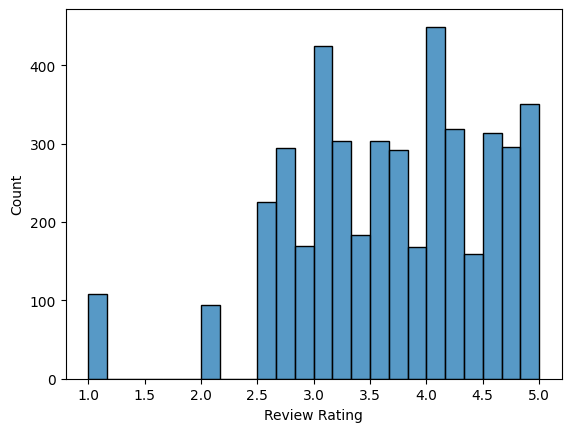

In [32]:
sns.histplot(df['Review Rating'])
df['Review Rating'].skew()

In [33]:
#Filling nulls of size with mode of each item purchased
df['Review Rating']=df['Review Rating'].fillna(df.groupby('Item Purchased')['Review Rating'].transform('median'))

In [34]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   object 
 7   Size                    5050 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           5050 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Previous Purchases      4502 non-null   

#Previous purchase

In [35]:
# null would be filled with 0 as null are those without any purchases before
df['Previous Purchases']=df['Previous Purchases'].fillna(0)

#Purchase amount

np.float64(3.3454377364917365)

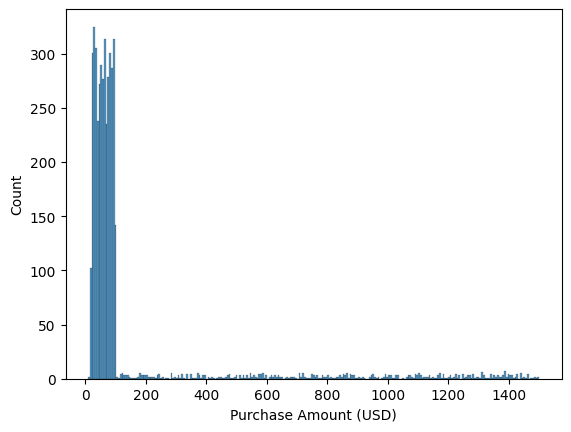

In [36]:
sns.histplot(df['Purchase Amount (USD)'])
df['Purchase Amount (USD)'].skew()

## Purchase amount is skewed positively, so nulls can't be filled with mean. We shall fill those with item purchased groupwise median.

In [37]:
#checking diff between mean and median
df.groupby('Item Purchased')['Purchase Amount (USD)'].agg(['mean','median','count'])


,mean,median,count
Item Purchased,,,
Backpack,60.111111,59.000,144
Bag,735.773625,766.850,80
Belt,59.993902,59.500,164
Blouse,60.802326,61.500,172
Boots,62.616438,65.500,146
Coat,57.851852,55.000,162
Dress,62.168675,63.500,166
Gloves,60.550000,61.500,140
Handbag,57.987261,57.000,157


In [38]:
df['Purchase Amount (USD)']=df['Purchase Amount (USD)'].fillna(df.groupby('Item Purchased')['Purchase Amount (USD)'].transform('median'))

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   5050 non-null   float64
 6   Location                5050 non-null   object 
 7   Size                    5050 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           5050 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Previous Purchases      5050 non-null   

#Checking Duplicates

In [40]:
df[df.duplicated()].sort_values(by='Customer ID')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
3698,172,29,Male,Shorts,Clothing,35.0,Virginia,M,Blue,Summer,3.6,Yes,Store Pickup,Yes,4.0,Credit Card,Weekly
4059,227,29,Male,Shoes,Footwear,74.0,Texas,Not Available,Violet,Spring,3.3,Yes,Free Shipping,Yes,5.0,PayPal,Monthly
3036,258,20,Male,Handbag,Accessories,53.0,West Virginia,Free Size,Red,Summer,4.5,Yes,Express,Yes,5.0,Credit Card,Quarterly
3742,323,41,Male,Belt,Accessories,95.0,Tennessee,Free Size,Cyan,Winter,3.0,Yes,Standard,Yes,47.0,Credit Card,Monthly
4468,473,20,Male,Jeans,Clothing,39.0,Georgia,L,Gray,Winter,3.9,Yes,Free Shipping,Yes,3.0,Bank Transfer,Quarterly
3390,603,37,Male,Shoes,Footwear,58.0,Oregon,Not Available,Lavender,Summer,4.2,Yes,Next Day Air,Yes,10.0,Cash,Every 3 Months
3843,615,68,Male,Jewelry,Accessories,85.0,Idaho,Free Size,Lavender,Winter,4.0,Yes,Standard,Yes,21.0,Credit Card,Bi-Weekly
1509,974,60,Male,Jacket,Outerwear,75.0,Colorado,M,Teal,Fall,3.5,Yes,2-Day Shipping,Yes,30.0,Bank Transfer,Quarterly
2630,992,20,Male,Shorts,Clothing,97.0,Wisconsin,XL,White,Spring,2.7,Yes,Standard,Yes,40.0,Bank Transfer,Bi-Weekly
4901,1060,22,Male,Jacket,Outerwear,34.0,North Carolina,M,Beige,Winter,2.5,No,Standard,Yes,25.0,Debit Card,Monthly


In [41]:
df = df.drop_duplicates(subset='Customer ID', keep='first')

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5000 non-null   int64  
 1   Age                     5000 non-null   int64  
 2   Gender                  5000 non-null   object 
 3   Item Purchased          5000 non-null   object 
 4   Category                5000 non-null   object 
 5   Purchase Amount (USD)   5000 non-null   float64
 6   Location                5000 non-null   object 
 7   Size                    5000 non-null   object 
 8   Color                   5000 non-null   object 
 9   Season                  5000 non-null   object 
 10  Review Rating           5000 non-null   float64
 11  Subscription Status     5000 non-null   object 
 12  Shipping Type           5000 non-null   object 
 13  Discount Applied        5000 non-null   object 
 14  Previous Purchases      5000 non-null   float

#We could also convert their datatypes like objects to categories to reduce memory. But data is less so we dont need to.

#After cleaning is done, we would do univariate analysis and look for outliers

In [45]:
df.describe()
#df.describe().columns

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,2522.280000,44.188000,193.162762,3.61218,22.467800
std,1473.224755,15.272148,311.293186,0.83352,15.801054
min,1.000000,18.000000,10.120000,1.00000,0.000000
25%,1250.750000,31.000000,44.000000,3.00000,8.000000
50%,2500.500000,44.000000,71.000000,3.60000,22.000000
75%,3750.250000,57.000000,94.000000,4.30000,36.000000
max,5099.000000,70.000000,1499.760000,5.00000,50.000000


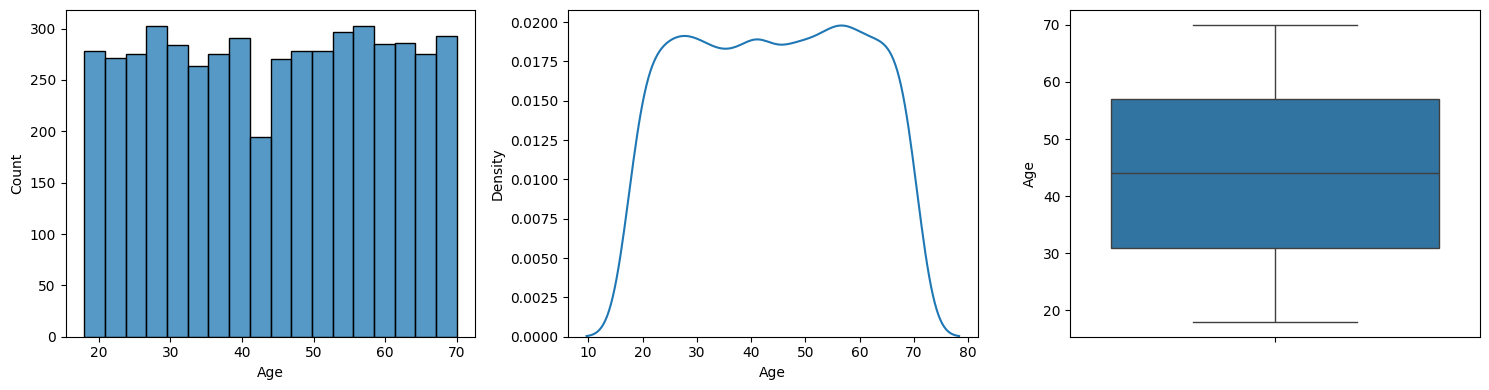

np.float64(-0.018540789039721634)

In [46]:
fig = plt.figure(figsize=(15,4))
ax1=fig.add_subplot(1,3,1)
sns.histplot(x=df['Age'])

ax2=fig.add_subplot(1,3,2)
sns.kdeplot(x=df['Age'])

ax3=fig.add_subplot(1,3,3)
sns.boxplot(y=df['Age'])

plt.tight_layout()
plt.show()

df['Age'].skew()


#Outliers in Purchase Amount (USD)

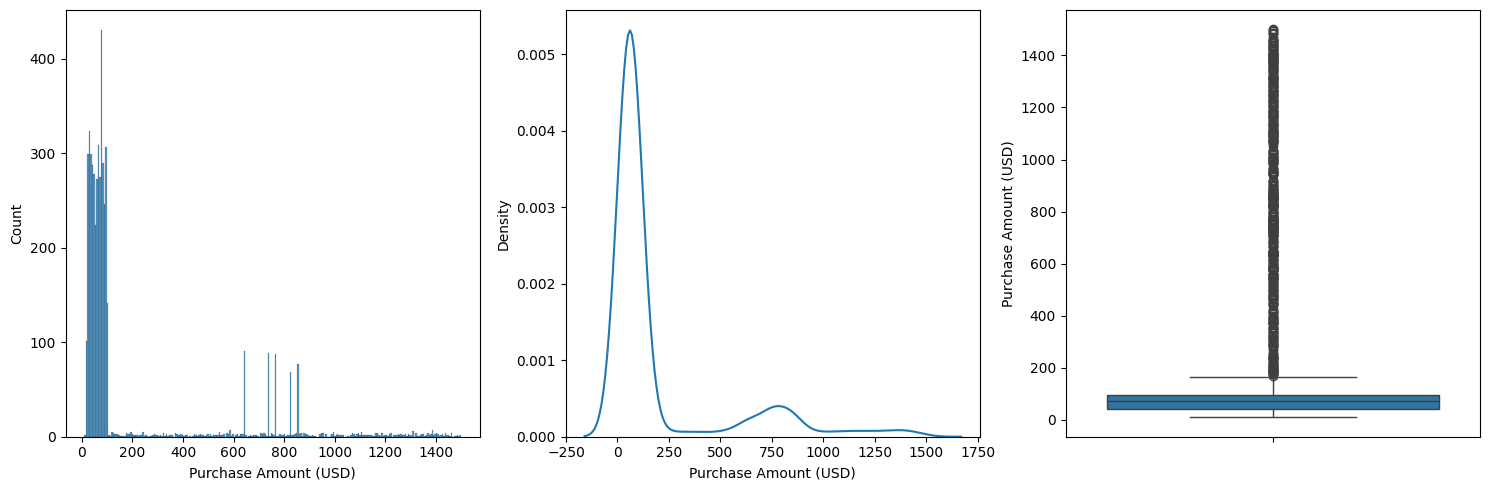

In [47]:
fig = plt.figure(figsize=(15,5))
ax1=fig.add_subplot(1,3,1)
sns.histplot(x=df['Purchase Amount (USD)'])

ax2=fig.add_subplot(1,3,2)
sns.kdeplot(x=df['Purchase Amount (USD)'])

ax3=fig.add_subplot(1,3,3)
sns.boxplot(y=df['Purchase Amount (USD)'])

plt.tight_layout()
plt.show()

In [48]:
df['Purchase Amount (USD)'].skew()

np.float64(2.2635374343311563)

In [49]:
df[df['Purchase Amount (USD)']>200].sort_values(by='Purchase Amount (USD)')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
990,4442,37,Male,Shoes,Footwear,201.930,Houston,Not Available,Black,Spring,3.7,No,Express,Yes,0.0,Credit Card,Weekly
2884,4536,41,Male,Watch,Electronics,202.120,New York,Not Applicable,Blue,Summer,2.0,No,Standard,No,0.0,Cash,Weekly
3466,4953,30,Male,Bag,Accessories,207.050,Phoenix,Free Size,White,Spring,3.0,No,Standard,No,0.0,Credit Card,Monthly
72,4558,41,Other,Bag,Accessories,208.020,Los Angeles,Free Size,White,Autumn,3.0,No,Standard,Yes,0.0,PayPal,Monthly
3125,5056,38,Female,Shirt,Clothing,210.550,Phoenix,M,White,Autumn,3.0,No,Standard,No,0.0,PayPal,Quarterly
1628,4032,23,Female,Shirt,Clothing,213.140,Phoenix,L,White,Winter,3.5,Yes,Express,Yes,0.0,Credit Card,Monthly
4209,4046,57,Female,Phone,Electronics,216.550,Phoenix,Not Applicable,Black,Winter,4.0,Yes,Express,Yes,21.0,Debit Card,Weekly
907,5052,24,Female,Headphones,Electronics,220.250,New York,Not Applicable,Red,Autumn,3.0,Yes,Express,No,0.0,Cash,Quarterly
3859,4267,25,Male,Shoes,Footwear,221.060,Houston,Not Available,Black,Autumn,3.7,Yes,Express,No,0.0,Cash,Weekly
3204,4223,59,Male,Phone,Electronics,227.000,New York,Not Applicable,Green,Winter,4.0,No,Express,No,0.0,PayPal,Quarterly


#Checking the probable reason for outliers

In [50]:
df.loc[df['Purchase Amount (USD)']>200,['Item Purchased','Purchase Amount (USD)','Shipping Type','Discount Applied']].sort_values(by=['Item Purchased','Purchase Amount (USD)'])
#

,Item Purchased,Purchase Amount (USD),Shipping Type,Discount Applied
3466,Bag,207.050,Standard,No
72,Bag,208.020,Standard,Yes
1058,Bag,236.320,Express,No
472,Bag,253.940,Standard,Yes
2648,Bag,294.040,Express,No
394,Bag,316.210,Express,No
1987,Bag,322.810,Express,No
4078,Bag,398.160,Standard,Yes
4998,Bag,409.980,Standard,Yes
493,Bag,468.460,Standard,No


In [51]:
df.groupby(['Category','Item Purchased']).agg({'Purchase Amount (USD)':'mean'}).sort_values(by=['Category','Purchase Amount (USD)'],ascending=[True,False])

Purchase Amount (USD)
Category    Item Purchased                       
Accessories Bag                        751.690793
            Scarf                       60.898089
            Hat                         60.876623
            Gloves                      60.550000
            Backpack                    60.391608
            Sunglasses                  59.931677
            Belt                        59.844720
            Jewelry                     58.538012
            Handbag                     57.888889
Clothing    Shirt                      241.684381
            T-shirt                     62.911565
            Dress                       62.168675
            Blouse                      60.877193
            Jeans                       60.870968
            Shorts                      60.082803
            Skirt                       59.506329
            Pants                       59.005848
            Socks                       58.188679
            Hoodie                      58.059603
            Sweater                     57.695122
Electronics Headphones                 841.691386
            Laptop                     815.597727
            Phone                      735.266082
            Watch                      660.432516
Footwear    Shoes                      221.542211
            Boots                       62.625000
            Sneakers                    59.551724
            Sandals                     57.500000
Outerwear   Coat                        57.608696
            Jacket                      56.742331

#The outliers have been observed in total of 7 products, i.e

**SHIRT, SHOES, LAPTOP, PHONE, BAG, WATCH, HEADPHONES**

> it is possible that they were part of the electronics before data cleaning, hence all of these have same range of purchase price.


> For now their high price would be replaced with the average price of their category products after cleaning.










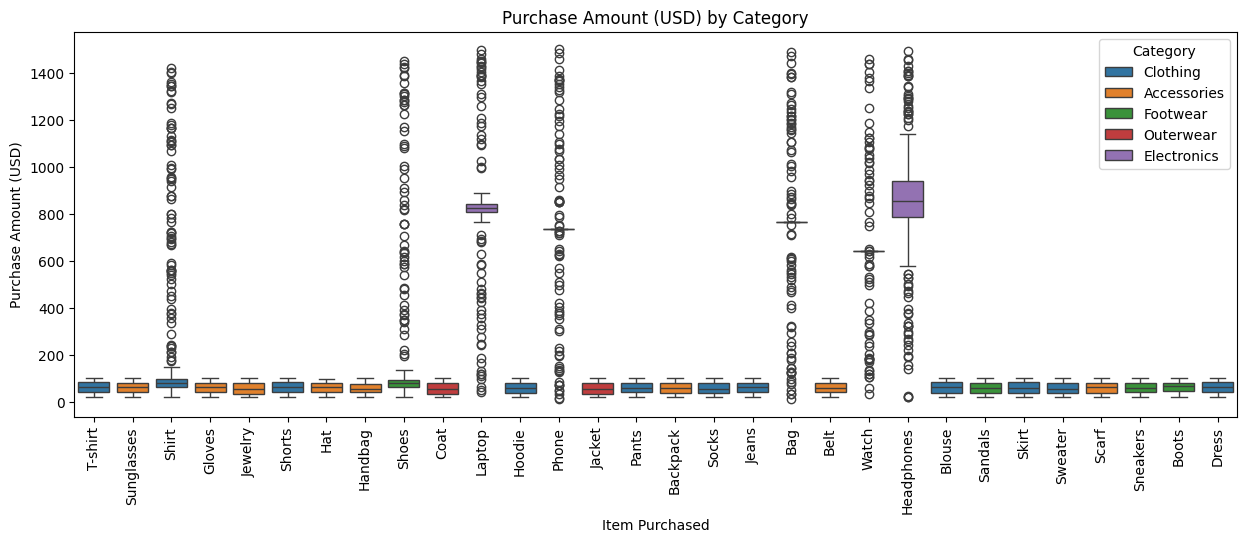

In [52]:
plt.figure(figsize=(15,5))
sns.boxplot(hue=df['Category'],y=df['Purchase Amount (USD)'],x=df['Item Purchased'])
plt.title('Purchase Amount (USD) by Category')
plt.xticks(rotation=90)
plt.show()

In [53]:
for i in ['Shirt','Shoes','Laptop','Phone','Bag','Watch','Headphones']:

 # Using a lambda to ensure only the first mode value is returned as a scalar
  stats = df[df['Item Purchased']==i]['Purchase Amount (USD)'].agg(['mean', 'median', lambda x: x.mode()[0]])
  stats.index = ['mean', 'median', 'mode']
  print(i)
  display(stats)

Shirt


,Purchase Amount (USD)
mean,241.684381
median,78.000000
mode,78.000000


Shoes


,Purchase Amount (USD)
mean,221.542211
median,78.000000
mode,78.000000


Laptop


...

,Purchase Amount (USD)
mean,751.690793
median,766.850000
mode,766.850000


Watch


,Purchase Amount (USD)
mean,660.432516
median,641.485000
mode,641.485000


Headphones


,Purchase Amount (USD)
mean,841.691386
median,854.555000
mode,854.555000


#Replacing values of those 7 products with their median to remove outliers

In [54]:
for i in ['Shirt','Shoes','Laptop','Phone','Bag','Watch','Headphones']:
    # Calculate median as a scalar
    median_val = df.loc[df['Item Purchased'] == i, 'Purchase Amount (USD)'].median()
    # Assign the scalar to the column (no brackets around column name to ensure correct broadcasting)
    df.loc[df['Item Purchased'] == i, 'Purchase Amount (USD)'] = median_val

# Verify counts again
print(df.groupby('Category')['Purchase Amount (USD)'].agg(['mean','median','count']))

                   mean  median  count
Category                              
Accessories  142.424074   65.00   1404
Clothing      62.932554   68.00   1883
Electronics  763.902292  736.01    637
Footwear      67.136968   78.00    752
Outerwear     57.172840   54.50    324


<Axes: xlabel='Category', ylabel='Purchase Amount (USD)'>

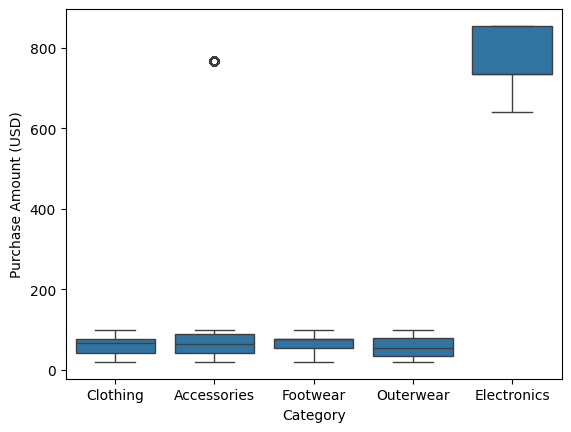

In [55]:
sns.boxplot(x=df['Category'], y=df['Purchase Amount (USD)'])

In [56]:
df[(df['Category'] == 'Accessories') & (df['Purchase Amount (USD)'] > 200)]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
35,5042,46,Other,Bag,Accessories,766.85,Los Angeles,Free Size,White,Summer,3.0,Yes,Express,No,31.0,PayPal,Monthly
39,4894,24,Other,Bag,Accessories,766.85,Los Angeles,Free Size,Red,Spring,3.0,No,Standard,No,4.0,PayPal,Quarterly
51,4708,33,Female,Bag,Accessories,766.85,New York,Free Size,Green,Winter,4.0,Yes,Standard,Yes,31.0,Debit Card,Quarterly
72,4558,41,Other,Bag,Accessories,766.85,Los Angeles,Free Size,White,Autumn,3.0,No,Standard,Yes,0.0,PayPal,Monthly
109,4972,46,Other,Bag,Accessories,766.85,New York,Free Size,White,Autumn,4.0,No,Express,Yes,3.0,Debit Card,Monthly
162,5024,38,Other,Bag,Accessories,766.85,Los Angeles,Free Size,Green,Summer,3.0,Yes,Express,Yes,0.0,Debit Card,Quarterly
212,4257,60,Other,Bag,Accessories,766.85,Houston,Free Size,Green,Winter,3.0,Yes,Express,No,11.0,Cash,Quarterly
262,4214,34,Other,Bag,Accessories,766.85,Phoenix,Free Size,Red,Autumn,1.0,Yes,Express,No,15.0,PayPal,Monthly
276,4557,51,Other,Bag,Accessories,766.85,Los Angeles,Free Size,Blue,Spring,3.0,Yes,Express,Yes,0.0,PayPal,Weekly
328,4905,41,Female,Bag,Accessories,766.85,Los Angeles,Free Size,White,Spring,3.0,No,Standard,Yes,0.0,PayPal,Quarterly


In [57]:
df.groupby('Category')['Purchase Amount (USD)'].agg(['mean','median','count'])

,mean,median,count
Category,,,
Accessories,142.424074,65.00,1404
Clothing,62.932554,68.00,1883
Electronics,763.902292,736.01,637
Footwear,67.136968,78.00,752
Outerwear,57.172840,54.50,324


In [58]:
#df.groupby(['Category', 'Item Purchased'])['Purchase Amount (USD)'].mean().reset_index().sort_values(by=['Category', 'Purchase Amount (USD)'], ascending=[True, False])


<Axes: ylabel='Purchase Amount (USD)'>

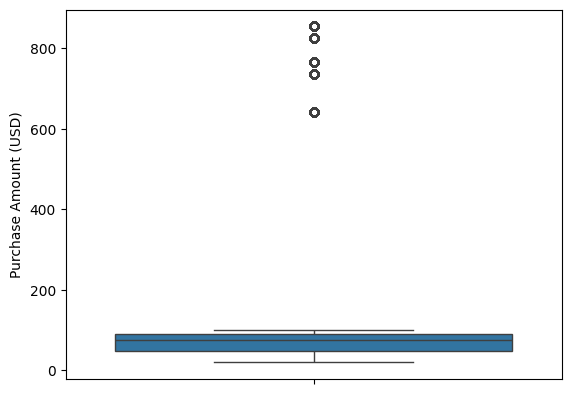

In [59]:
sns.boxplot(y=df['Purchase Amount (USD)'])

In [60]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,2522.280000,44.188000,174.816432,3.61218,22.467800
std,1473.224755,15.272148,260.128094,0.83352,15.801054
min,1.000000,18.000000,20.000000,1.00000,0.000000
25%,1250.750000,31.000000,47.000000,3.00000,8.000000
50%,2500.500000,44.000000,76.000000,3.60000,22.000000
75%,3750.250000,57.000000,91.000000,4.30000,36.000000
max,5099.000000,70.000000,854.555000,5.00000,50.000000


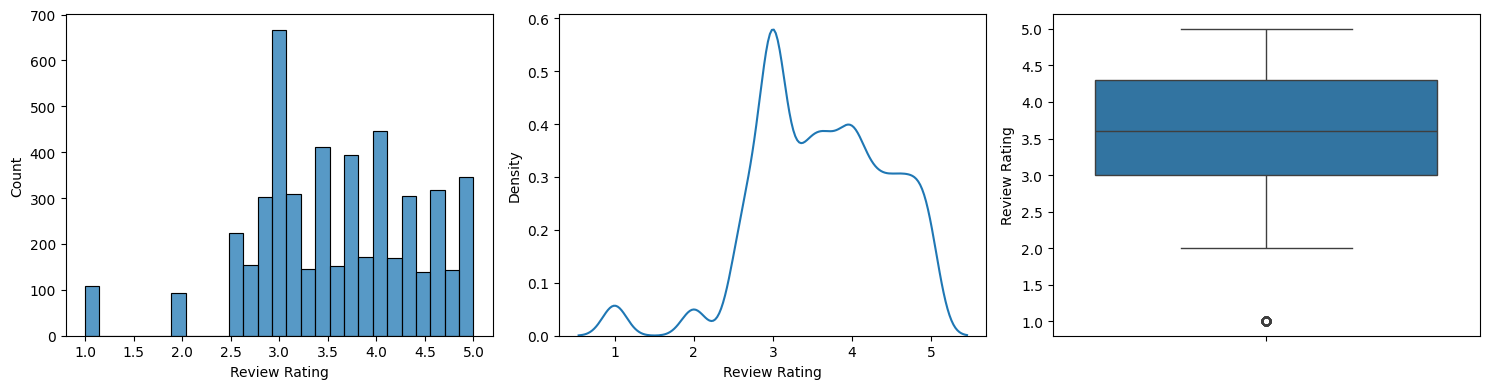

np.float64(-0.44382858529597924)

In [61]:
fig = plt.figure(figsize=(15,4))
ax1=fig.add_subplot(1,3,1)
sns.histplot(x=df['Review Rating'])

ax2=fig.add_subplot(1,3,2)
sns.kdeplot(x=df['Review Rating'])

ax3=fig.add_subplot(1,3,3)
sns.boxplot(y=df['Review Rating'])

plt.tight_layout()
plt.show()

df['Review Rating'].skew()


In [62]:
df[df['Review Rating']<2.0]['Review Rating'].value_counts()

,count
Review Rating,
1.0,108


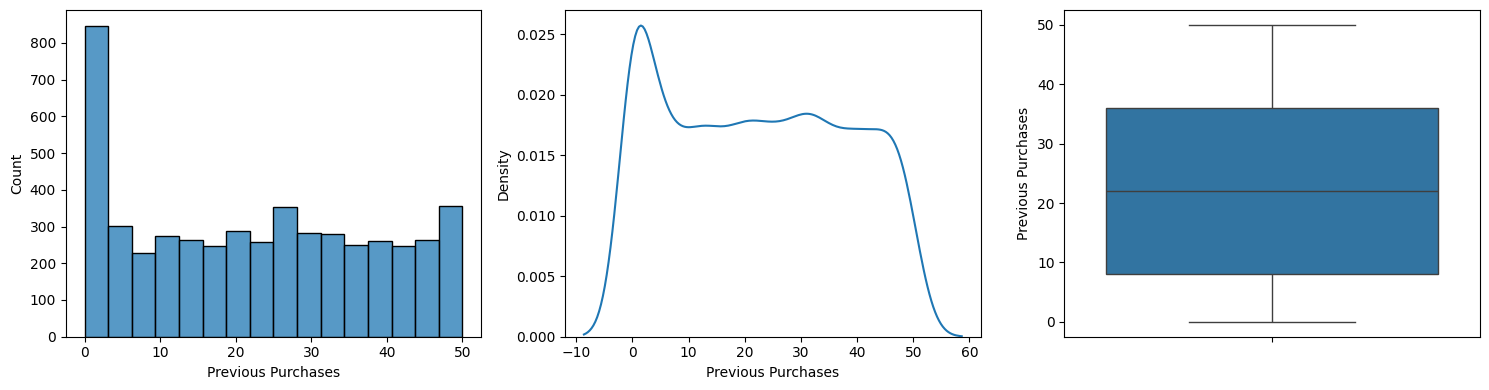

np.float64(0.08659239051051142)

In [63]:
fig = plt.figure(figsize=(15,4))
ax1=fig.add_subplot(1,3,1)
sns.histplot(x=df['Previous Purchases'])

ax2=fig.add_subplot(1,3,2)
sns.kdeplot(x=df['Previous Purchases'])

ax3=fig.add_subplot(1,3,3)
sns.boxplot(y=df['Previous Purchases'])

plt.tight_layout()
plt.show()

df['Previous Purchases'].skew()


In [64]:
df.describe(include='O')

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Payment Method,Frequency of Purchases
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,3,30,5,54,7,25,5,2,6,2,6,7
top,Male,Shirt,Clothing,New York,Free Size,Black,Spring,No,Standard,No,Cash,Monthly
freq,2989,315,1883,337,1404,402,1266,3421,1201,2756,944,936


In [65]:
df1 = df.copy()

In [66]:
df.to_csv('cust_behav_cleaned_data.csv',index=False)

#Renaming columns so that can be exported to SQL Server easily and used

In [67]:
df.columns = df.columns.str.replace(' ','_').str.lower()
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases'],
      dtype='object')

In [68]:
df= df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases'],
      dtype='object')

# Exporting our data to our database and making connection with it

In [69]:
user = 'dhriti'
password = 'root'
database = 'project_dh'
host = '0.tcp.in.ngrok.io'
port = '27138'

conn = create_engine(f'mysql+pymysql://{user}:{password}@{host}:{port}/{database}')


In [70]:
df.to_sql(name='cust_behav',con=conn,if_exists='replace',index=False)

5000

In [71]:
pd.read_sql('show tables',conn)

,Tables_in_project_dh
0,cust_behav


##BUSINESS INSIGHTS

###1. Which category generates highest revenue?

In [72]:
with conn.connect() as connection:
    df_category_sales = pd.read_sql("""
select category, round(sum(purchase_amount),2) as 'total_sales'
from cust_behav
group by category
order by total_sales desc;
""",connection)
df_category_sales

,category,total_sales
0,Electronics,486605.76
1,Accessories,199963.40
2,Clothing,118502.00
3,Footwear,50487.00
4,Outerwear,18524.00


### 1. Insight
The Electronics category generates the highest revenue at **$486,605.76**, which is significantly more than any other category, accounting for approximately **55.67%** of the total revenue.

### 1. Recommendation
Focus marketing efforts and inventory management on the Electronics category, given its high revenue generation potential. Consider expanding product lines within Electronics that align with current customer demand.

##Are discounts actually increasing purchase value?

In [73]:

pd.read_sql("""
select category, discount_applied,
round(sum(purchase_amount)) as 'total_sales',
round(sum(sum(purchase_amount)) over (partition by category)) as 'total_per_category',
round(sum(purchase_amount)/sum(sum(purchase_amount)) over (partition by category)*100) as 'percent_contribution',
round(sum(sum(purchase_amount)) over (partition by discount_applied)) as 'total_per_discount'
from cust_behav
group by category , discount_applied
order by category asc, total_sales desc;
""",conn)

,category,discount_applied,total_sales,total_per_category,percent_contribution,total_per_discount
0,Accessories,No,109156.0,199963.0,55.0,452042.0
1,Accessories,Yes,90807.0,199963.0,45.0,422040.0
2,Clothing,No,67008.0,118502.0,57.0,452042.0
3,Clothing,Yes,51494.0,118502.0,43.0,422040.0
4,Electronics,Yes,248597.0,486606.0,51.0,422040.0
5,Electronics,No,238008.0,486606.0,49.0,452042.0
6,Footwear,No,27312.0,50487.0,54.0,452042.0
7,Footwear,Yes,23175.0,50487.0,46.0,422040.0
8,Outerwear,No,10558.0,18524.0,57.0,452042.0
9,Outerwear,Yes,7966.0,18524.0,43.0,422040.0


### 2. Insight
Discounts are not consistently increasing overall purchase value across all categories. In fact, most categories (Accessories, Clothing, Footwear, Outerwear) show higher sales when no discount is applied. For instance, in Accessories, **$109,156** was generated without discounts (55%), compared to **$90,807** with discounts (45%). Only Electronics shows a marginal increase in sales with discounts, generating **$248,597** (51%) with discounts versus **$238,008** (49%) without.

### 2. Recommendation
Re-evaluate the current discount strategy. Instead of broad discounts, consider targeted promotions. For Electronics, analyze if the slight increase in sales with discounts is profitable. For other categories, focus on value proposition and customer loyalty programs rather than relying heavily on discounts, as they appear to be cannibalizing full-price sales.

##3. What is the total revenue generated by male and female customer ?

In [74]:
with conn.connect() as connection:
    df_sales1 = pd.read_sql("""
select category, gender,
round(sum(sum(purchase_amount)) over ()) as'total_sales',
round(sum(sum(purchase_amount)) over (partition by gender)) as'sales_per_gender',
round(sum(sum(purchase_amount)) over( partition by category)) as 'sales_per_cat',
round(sum(sum(purchase_amount)) over (partition by category, gender)) as 'sales_per_gender_per_cat'
from cust_behav
group by category, gender
order by category asc, sales_per_gender_per_cat desc;
""",connection)
df_sales1

,category,gender,total_sales,sales_per_gender,sales_per_cat,sales_per_gender_per_cat
0,Accessories,Male,874082.0,349847.0,199963.0,88724.0
1,Accessories,Female,874082.0,308199.0,199963.0,59861.0
2,Accessories,Other,874082.0,216036.0,199963.0,51379.0
3,Clothing,Male,874082.0,349847.0,118502.0,76094.0
4,Clothing,Female,874082.0,308199.0,118502.0,38352.0
5,Clothing,Other,874082.0,216036.0,118502.0,4056.0
6,Electronics,Female,874082.0,308199.0,486606.0,186636.0
7,Electronics,Other,874082.0,216036.0,486606.0,157481.0
8,Electronics,Male,874082.0,349847.0,486606.0,142489.0
9,Footwear,Male,874082.0,349847.0,50487.0,29918.0


### 3. Insight
Male customers contribute the highest total sales with **$349,847**, followed by Female customers with **$308,199**, and then 'Other' genders with **$216,036**. Electronics is the leading category in terms of sales across all gender groups.

### 3. Recommendation
Tailor marketing and product recommendations to gender-specific preferences, especially for top-performing categories like Electronics. Explore opportunities to increase engagement and sales within the 'Other' gender segment.

##4. Which customer used a discount but still spent more then the average purchase amount ?

In [75]:
pd.read_sql("""
select customer_id, round(purchase_amount,2), discount_applied,
(select round(avg(purchase_amount),2) from cust_behav) as 'total_avg'
from cust_behav
where discount_applied = 'Yes' and purchase_amount > (select avg(purchase_amount) from cust_behav)
order by purchase_amount desc;"""
,conn)

,customer_id,"round(purchase_amount,2)",discount_applied,total_avg
0,4576,854.56,Yes,174.82
1,4235,854.56,Yes,174.82
2,4011,854.56,Yes,174.82
3,4424,854.56,Yes,174.82
4,4237,854.56,Yes,174.82
5,4790,854.56,Yes,174.82
6,4225,854.56,Yes,174.82
7,4197,854.56,Yes,174.82
8,4284,854.56,Yes,174.82
9,4373,854.56,Yes,174.82


### 4. Insight
A substantial number of customers (**402 customers**) who received discounts still made purchases above the overall average purchase amount of **$174.82**. The highest single purchase amount with a discount was **$854.56**. This suggests that discounts, when applied, can motivate some customers to spend more than they typically would.

### 4. Recommendation
Analyze which specific customer segments or product types benefit most from discounts to drive higher individual purchase values. Use this information to create more strategic and effective discount campaigns, potentially targeting high-value customers or specific product bundles.

##5. Which are the top/bottom 5 products with the highest average review rating.

In [76]:
pd.read_sql("""
SELECT item_purchased, ROUND(AVG(review_rating),2) AS Avg_ratings
FROM cust_behav
GROUP BY item_purchased
ORDER BY Avg_ratings DESC
limit 5;"""
,conn)

,item_purchased,Avg_ratings
0,Gloves,3.86
1,Sandals,3.85
2,Boots,3.82
3,Hat,3.80
4,Skirt,3.79


### 5. Insight (Top 5 products with highest average review rating)
'Gloves' (**3.86**), 'Sandals' (**3.85**), 'Boots' (**3.82**), 'Hat' (**3.80**), and 'Skirt' (**3.79**) are the top 5 products with the highest average review ratings, indicating high customer satisfaction.

### 5. Recommendation
Leverage the strong positive reviews for these products in marketing campaigns. Promote them to new customers, feature them prominently on the website, and consider bundle offers with these highly-rated items to increase overall sales and customer trust.

In [77]:
pd.read_sql("""
SELECT item_purchased, ROUND(AVG(review_rating),2) AS Avg_ratings
FROM cust_behav
GROUP BY item_purchased
ORDER BY Avg_ratings ASC
limit 5;"""
,conn)

,item_purchased,Avg_ratings
0,Phone,2.97
1,Headphones,3.04
2,Watch,3.05
3,Laptop,3.09
4,Bag,3.09


### 6. Insight (Bottom 5 products with lowest average review rating)
'Phone' (**2.97**), 'Headphones' (**3.04**), 'Watch' (**3.05**), 'Laptop' (**3.09**), and 'Bag' (**3.09**) have the lowest average review ratings. These are predominantly high-value electronics and accessories.

### 6. Recommendation
Investigate the reasons behind the lower review ratings for these specific, often high-value, products. This could involve examining product quality, user experience, delivery issues, or customer support related to these items. Addressing these concerns is crucial to prevent negative impacts on overall sales and brand reputation.

##6. Average purchase: Standard vs Express shipping

In [78]:
pd.read_sql("""
SELECT shipping_type,
COUNT(DISTINCT customer_id) as order_placed,
ROUND(AVG(purchase_amount),2)  as avg_purchase,
ROUND(SUM(purchase_amount),2) AS revenue
FROM cust_behav
GROUP BY shipping_type
ORDER BY revenue DESC;"""
,conn)

,shipping_type,order_placed,avg_purchase,revenue
0,Standard,1201,298.82,358880.79
1,Express,1199,296.78,355833.36
2,Free Shipping,675,61.90,41784.00
3,Store Pickup,650,61.54,40002.00
4,2-Day Shipping,627,61.99,38865.00
5,Next Day Air,648,59.75,38717.00


### 7. Insight
Standard (**$358,880.79** revenue, **$298.82** average purchase) and Express (**$355,833.36** revenue, **$296.78** average purchase) shipping types account for the vast majority of revenue and orders placed, with significantly higher average purchase amounts compared to other shipping options. Free Shipping (**$41,784.00** revenue, **$61.90** average purchase), Store Pickup (**$40,002.00** revenue, **$61.54** average purchase), 2-Day Shipping (**$38,865.00** revenue, **$61.99** average purchase), and Next Day Air (**$38,717.00** revenue, **$59.75** average purchase) contribute much less.

### 7. Recommendation
Optimize operations and customer experience for Standard and Express shipping, as these are clearly preferred by customers, especially for higher-value purchases. Re-evaluate the cost-effectiveness and customer demand for the less popular shipping types; consider simplifying shipping options or promoting specific ones based on strategic goals.

##7. Do subscribed customers spend more ? Compare average spend and total revenue between subscribers and non-subscribers.

In [79]:
with conn.connect() as connection:
    df_subscription_category_revenue = pd.read_sql("""
SELECT category ,subscription_status,
COUNT(customer_id) as users,
ROUND(AVG(purchase_amount),2) as avg_revenue,
ROUND(SUM(purchase_amount),2) as total_revenue
FROM cust_behav
GROUP BY subscription_status, category
ORDER BY category asc, total_revenue DESC;
""",connection)
df_subscription_category_revenue

,category,subscription_status,users,avg_revenue,total_revenue
0,Accessories,No,987,118.21,116668.85
1,Accessories,Yes,417,199.75,83294.55
2,Clothing,No,1359,62.69,85191.00
3,Clothing,Yes,524,63.57,33311.00
4,Electronics,No,333,760.14,253126.35
5,Electronics,Yes,304,768.02,233479.40
6,Footwear,No,509,66.53,33862.00
7,Footwear,Yes,243,68.42,16625.00
8,Outerwear,No,233,56.59,13186.00
9,Outerwear,Yes,91,58.66,5338.00


In [80]:
pd.read_sql("""
SELECT subscription_status,
COUNT(customer_id) as users,
ROUND(AVG(purchase_amount),2) as avg_revenue,
ROUND(SUM(purchase_amount),2) as total_revenue
FROM cust_behav
GROUP BY subscription_status
ORDER BY total_revenue DESC;"""
,conn)

,subscription_status,users,avg_revenue,total_revenue
0,No,3421,146.75,502034.20
1,Yes,1579,235.62,372047.95


### 8. Insight
While non-subscribed customers (**3421 users**) generate a higher total revenue (**$502,034.20**), subscribed customers (**1579 users**) have a significantly higher average purchase amount (**$235.62** vs. **$146.75** for non-subscribers). This suggests that subscribers, though fewer in number, are more valuable per transaction.

### 8. Recommendation
Implement strategies to convert high-spending non-subscribers into subscribers to increase the overall average purchase value across the customer base. For existing subscribers, focus on retaining them and encouraging continued high-value purchases through exclusive benefits, personalized offers, and premium product access.

##8. Top 5 products with highest discount usage %

In [81]:
pd.read_sql("""
SELECT item_purchased,
COUNT(item_purchased) AS total_number_of_times_sold,
COUNT(CASE WHEN discount_applied='Yes' THEN 1 END) AS  Number_of_times_sold_when_disocunt_applied,
COUNT(CASE WHEN discount_applied='Yes' THEN 1 END) *100.0 / COUNT(*) AS discount_percent
FROM cust_behav
GROUP BY item_purchased
ORDER BY discount_percent DESC
limit 5;"""
,conn )

,item_purchased,total_number_of_times_sold,Number_of_times_sold_when_disocunt_applied,discount_percent
0,Laptop,143,74,51.74825
1,Phone,171,88,51.46199
2,Headphones,166,85,51.20482
3,Hat,154,77,50.00000
4,Watch,157,78,49.68153


### 9. Insight
Laptop (**51.75%**), Phone (**51.46%**), Headphones (**51.20%**), Hat (**50.00%**), and Watch (**49.68%**) are the products with the highest percentage of discount usage, indicating that customers are often buying these items when a discount is applied. This aligns with the understanding that these are often higher-ticket items where discounts can be a strong motivator.

### 9. Recommendation
Continue to strategically offer discounts on these high-value items, but ensure that the discounts are structured to maintain profitability. Consider using discounts as a tool for customer acquisition or for encouraging larger basket sizes by bundling these discounted items with other products.

##9. Segment customer into new, returning and loyal based on their total number of previous purchase, and show the count of each segment.

In [82]:
pd.read_sql("""
SELECT
CASE
	WHEN previous_purchases= '0' THEN 'New Customer'
	WHEN previous_purchases BETWEEN 1 AND 15  THEN 'Returning Customer'
	ELSE 'Loyal Customers'
END AS customer_segment,
COUNT(*) AS customer_count
FROM cust_behav
GROUP BY customer_segment;"""
,conn)

,customer_segment,customer_count
0,Loyal Customers,3085
1,Returning Customer,1354
2,New Customer,561


### 10. Insight
'Loyal Customers' (those with more than 15 previous purchases) represent the largest segment of the customer base with **3085 customers**, followed by 'Returning Customers' (1-15 previous purchases) with **1354 customers**, and then 'New Customers' (0 previous purchases) with **561 customers**.

### 10. Recommendation
Develop tailored loyalty programs and exclusive benefits to further reward and retain the 'Loyal Customers' segment. Implement strategies to encourage 'New Customers' to make repeat purchases and transition 'Returning Customers' into 'Loyal Customers', as the latter group is the largest and likely most valuable.

##10. What are the top 3 most purchased products within each category ?

In [83]:
pd.read_sql("""
WITH CTE AS (
SELECT category, item_purchased,
COUNT(item_purchased) AS most_purchased,
DENSE_RANK() OVER (PARTITION BY category ORDER BY COUNT(item_purchased) DESC) AS RNK
FROM cust_behav
GROUP BY category,item_purchased)
SELECT * FROM CTE
WHERE RNK <=3;"""
,conn)

,category,item_purchased,most_purchased,RNK
0,Accessories,Jewelry,171,1
1,Accessories,Bag,164,2
2,Accessories,Sunglasses,161,3
3,Accessories,Belt,161,3
4,Clothing,Shirt,315,1
5,Clothing,Pants,171,2
6,Clothing,Blouse,171,2
7,Clothing,Dress,166,3
8,Electronics,Phone,171,1
9,Electronics,Headphones,166,2


### 11. Insight
The query identifies the top 3 most purchased items within each category, highlighting customer preferences. For instance, in Accessories, 'Jewelry' (**171 purchases**), 'Bag' (**164 purchases**), 'Sunglasses' (**161 purchases**), and 'Belt' (**161 purchases**) are popular. In Clothing, 'Shirt' (**315 purchases**), 'Pants' (**171 purchases**), 'Blouse' (**171 purchases**), and 'Dress' (**166 purchases**) are top. In Electronics, 'Phone' (**171 purchases**), 'Headphones' (**166 purchases**), and 'Watch' (**157 purchases**) are the most popular. In Footwear, 'Shoes' (**303 purchases**), 'Sandals' (**160 purchases**), and 'Sneakers' (**145 purchases**) are the most popular. In Outerwear, 'Jacket' (**163 purchases**) and 'Coat' (**161 purchases**) are the top products.

### 11. Recommendation
Ensure robust inventory management for these top-performing products to avoid stockouts. Utilize these popular items as anchors in marketing campaigns, cross-selling, and upselling strategies to maximize sales across categories.

##11. Are customers who are repeat buyers (more than 5 previous purchases) also likely to subscribe ?

In [84]:
pd.read_sql("""
SELECT
	CASE
		WHEN previous_purchases > 5 THEN 'Repeat Buyers'
		ELSE 'Normal Buyers'
	END AS customer_type,
	subscription_status,
	COUNT(*) AS customer_count,
	COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY CASE
										WHEN previous_purchases > 5 THEN 'Repeat Buyers'
										ELSE 'Normal Buyers'
									    END) AS percents
FROM cust_behav
GROUP BY CASE
		WHEN previous_purchases > 5 THEN 'Repeat Buyers'
		ELSE 'Normal Buyers'
	END,subscription_status;"""
  ,conn)

,customer_type,subscription_status,customer_count,percents
0,Normal Buyers,No,658,62.84623
1,Normal Buyers,Yes,389,37.15377
2,Repeat Buyers,No,2763,69.89628
3,Repeat Buyers,Yes,1190,30.10372


### 12. Insight
Interestingly, 'Repeat Buyers' (those with more than 5 previous purchases) are less likely to be subscribed (**30.10%** subscribed) compared to 'Normal Buyers' (37.15% subscribed). This suggests a missed opportunity for subscription conversion among a valuable customer segment.

### 12. Recommendation
Investigate why repeat buyers are less inclined to subscribe. Potential reasons could be a lack of awareness of subscription benefits, or the current benefits not aligning with their purchasing patterns. Develop targeted subscription incentives or exclusive offers specifically for repeat buyers to encourage higher subscription rates within this loyal customer group.

##12. What is the revenue contribution of each age group ?

In [85]:
pd.read_sql("""
SELECT
	CASE
		WHEN age BETWEEN 18 AND 25 THEN '18-25'
		WHEN Age BETWEEN 26 AND 35 THEN '26-35'
		WHEN Age BETWEEN 36 AND 50 THEN '35-50'
		ELSE '51+'
	END AS age_group,
	ROUND(SUM(purchase_amount),2) AS total_revenue
FROM cust_behav
GROUP BY CASE
		WHEN age BETWEEN 18 AND 25 THEN '18-25'
		WHEN Age BETWEEN 26 AND 35 THEN '26-35'
		WHEN Age BETWEEN 36 AND 50 THEN '35-50'
		ELSE '51+'
	END
	ORDER BY total_revenue DESC;"""
  ,conn)

,age_group,total_revenue
0,51+,344346.22
1,35-50,237185.78
2,26-35,160590.77
3,18-25,131959.38


### 13. Insight
The age group '51+' contributes the highest total revenue (**$344,346.22**), followed by '35-50' (**$237,185.78**), '26-35' (**$160,590.77**), and '18-25' (**$131,959.38**). This indicates that older demographics are the primary revenue drivers.

### 13. Recommendation
Tailor marketing campaigns, product assortments, and website user experience to cater to the preferences and purchasing habits of the '51+' and '35-50' age groups, as they represent the most significant revenue contributors. Consider how to engage and grow the younger demographics for future revenue growth.

##13. What is the sales per payment method?

In [86]:
pd.read_sql("""
select payment_method,
round(sum(purchase_amount),2) as 'sales_per_method' from cust_behav
group by payment_method;"""
,conn)

,payment_method,sales_per_method
0,Cash,199100.51
1,Debit Card,218611.23
2,Credit Card,193355.27
3,PayPal,187502.15
4,Venmo,38025.00
5,Bank Transfer,37488.00


### 14. Insight
'Debit Card' (**$218,611.23**), 'Cash' (**$199,100.51**), and 'Credit Card' (**$193,355.27**) are the top three payment methods by total sales, collectively accounting for the vast majority of transactions. 'PayPal' (**$187,502.15**), 'Venmo' (**$38,025.00**), and 'Bank Transfer' (**$37,488.00**) have significantly lower sales.

### 14. Recommendation
Ensure a seamless and secure payment experience for Debit Card, Cash, and Credit Card users, as these are the most preferred methods. While maintaining support for all options, consider if any strategic promotional efforts or system improvements can be made for 'PayPal' or 'Bank Transfer' if there's a goal to increase their usage, or prioritize resources on optimizing the most popular methods.

##14. What is the sales per season?

In [87]:
pd.read_sql("""
select season,
sum(purchase_amount) as 'sales_per_season' from cust_behav
group by season;"""
,conn)

,season,sales_per_season
0,Winter,211657.145
1,Spring,218657.770
2,Fall,60834.000
3,Summer,217132.645
4,Autumn,165800.600


### 15. Insight
'Spring' (**$218,657.77**), 'Summer' (**$217,132.645**), and 'Winter' (**$211,657.145**) are the highest-grossing seasons in terms of total sales, with 'Autumn' (**$165,800.60**) and 'Fall' (**$60,834.00**) showing considerably lower revenue contributions.

### 15. Recommendation
Plan inventory, marketing campaigns, and promotions strategically around the peak seasons (Spring, Summer, Winter) to maximize sales. For 'Fall' and 'Autumn', analyze the reasons for lower sales (e.g., product offerings, consumer behavior during these times) and develop targeted strategies, such as unique seasonal collections or special events, to boost revenue.

##15. Sales per size within category.

In [88]:
with conn.connect() as connection:
    df_sales2 = pd.read_sql("""
select category, size,
sum(purchase_amount) as 'sales_per_size',
sum(sum(purchase_amount)) over (partition by category) as'sales_per_cat'
from cust_behav
where category in ('Clothing','Outerwear')
group by category, size
order by category asc, sales_per_size desc;"""
,connection)
df_sales2

,category,size,sales_per_size,sales_per_cat
0,Clothing,M,54640.0,118502.0
1,Clothing,L,30661.0,118502.0
2,Clothing,S,20349.0,118502.0
3,Clothing,XL,12852.0,118502.0
4,Outerwear,M,8334.0,18524.0
5,Outerwear,L,5259.0,18524.0
6,Outerwear,S,3159.0,18524.0
7,Outerwear,XL,1772.0,18524.0


### 16. Insight
Within both 'Clothing' and 'Outerwear' categories, 'M' (Medium) size consistently generates the highest sales. For 'Clothing', 'M' size generated **$54,640.0**, followed by 'L' (**$30,661.0**), 'S' (**$20,349.0**), and 'XL' (**$12,852.0**). Similarly for 'Outerwear', 'M' size generated **$8,334.0**, followed by 'L' (**$5,259.0**), 'S' (**$3,159.0**), and 'XL' (**$1,772.0**).

### 16. Recommendation
Adjust inventory management and procurement based on the sales performance of different sizes within Clothing and Outerwear categories. Ensure sufficient stock of 'M' and 'L' sizes to meet high demand, and consider optimizing the allocation or display of less popular sizes ('S' and 'XL') to improve their sales.